In [2]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("/Users/akashdeepsangwan/Desktop/ML/ML/GitHub-Collab/Machine-Learning/k-means cluster/Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.drop(columns= ["CustomerID", "Gender", "Age"], inplace = True)

In [6]:
data.head(10)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76
6,18,6
7,18,94
8,19,3
9,19,72


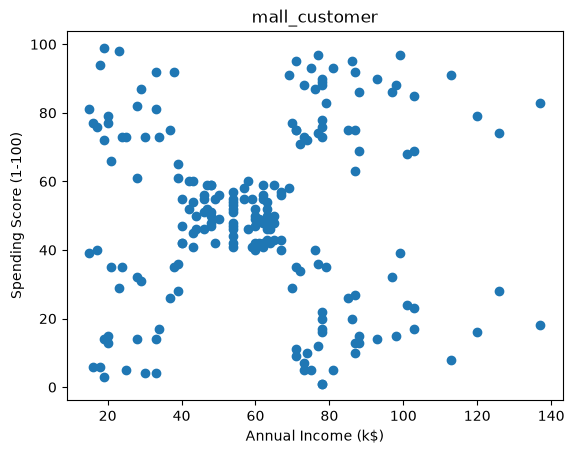

In [ ]:
plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("mall_customer")
plt.show()


- DBCSAN uses Euclidean Distance. Income and Spending score are on the different scales

In [17]:
from sklearn.preprocessing import StandardScaler
X= data[['Annual Income (k$)', 'Spending Score (1-100)']].values
X_scaled = StandardScaler().fit_transform(X)

In [18]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [20]:
print(np.mean(X_scaled), "\n", np.std(X_scaled) )

-1.7985612998927537e-16 
 1.0


- On what basis the Eps and min_samples size are decided ??

In [35]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 0.35, min_samples=5)
dbscan.fit(X_scaled)
labels = dbscan.labels_
n_clusters = len(set(labels)) - (1 if -1 in  labels else 0)
print("No. of clusters : ", n_clusters)
print("Noise Points : ", list(labels).count(-1) )

No. of clusters :  6
Noise Points :  23


In [34]:
print(pd.Series(labels).value_counts().sort_index())

-1    23
 0    16
 1    12
 2     7
 3    88
 4    31
 5    23
Name: count, dtype: int64


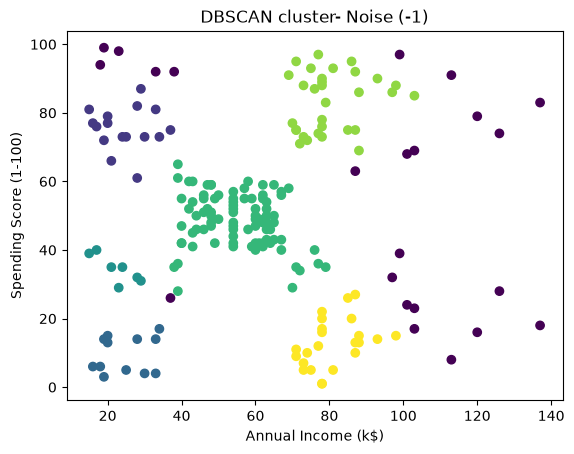

In [36]:
plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c= labels)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN cluster- Noise (-1)")
plt.show()

### EPS

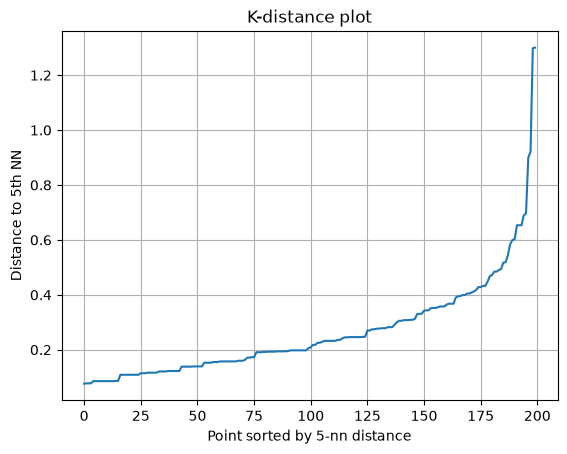

In [40]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5
nn = NearestNeighbors(n_neighbors = min_samples)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, min_samples -1]) # distance to 5th neighbor

plt.plot(k_dist)
plt.xlabel("Point sorted by 5-nn distance")
plt.ylabel("Distance to 5th NN")
plt.title("K-distance plot")
plt.grid(True)
plt.show()